# Análisis de Valores Únicos por Categoría en 'Area'

Este notebook realiza un análisis exploratorio del dataset para determinar cuántos valores únicos existen para cada una de las categorías definidas en la característica **Area**.

---

## 1. Importación de Librerías y Configuración

Utilizaremos `pandas` para el manejo de datos y `pathlib` para gestionar las rutas de forma robusta.

In [1]:
import pandas as pd
from pathlib import Path

# Definir la ruta del dataset original
dataset_path = Path("../data/raw/db_orig.csv")

if not dataset_path.exists():
    print(f"⚠️ El archivo no se encuentra en {dataset_path.absolute()}")
else:
    print(f"✅ Dataset localizado en: {dataset_path}")

✅ Dataset localizado en: ..\data\raw\db_orig.csv


## 2. Carga del Dataset

Cargamos los datos y visualizamos las primeras filas para confirmar la estructura.

In [2]:
try:
    df = pd.read_csv(dataset_path)
    display(df.head())
except Exception as e:
    print(f"Error al cargar el dataset: {e}")

,Description,Date,Amount,Area,Type
0,Entretenimiento,28/02/2026,"10,00€",Leisure,Expenses
1,Nómina mensual,27/02/2026,"629,58€",Salary,Income
2,Gasto vacaciones,25/02/2026,"51,00€","Leisure, Vacations",Expenses
3,Pequeño ocio,22/02/2026,"2,80€",Leisure,Expenses
4,Compra alimentación,21/02/2026,"24,80€",Food,Expenses


## 3. Análisis de Valores Únicos por Categoría de 'Area'

A continuación, calculamos cuántos valores únicos hay en el resto de las columnas para cada categoría de la característica `Area`.

> **Nota:** El método `.nunique()` aplicado tras un agrupamiento nos indica la cantidad de elementos distintos dentro de cada grupo.

In [3]:
# Calculamos los valores únicos por cada categoría de Area
unique_counts_per_area = df.groupby('Area').nunique()

print("Conteo de valores únicos por cada categoría en 'Area':")
display(unique_counts_per_area)

Conteo de valores únicos por cada categoría en 'Area':


,Description,Date,Amount,Type
Area,,,,
Deposit,2,85,35,1
Food,3,160,130,1
"Food, Vacations",1,10,17,1
Investment,4,63,13,1
Invoice,4,214,138,1
"Invoice, Vacations",1,11,11,1
Leisure,4,154,112,1
"Leisure, Vacations",2,14,15,1
Salary,1,80,45,1


### Detalle específico: Descripciones únicas por Area

Si lo que buscamos es saber cuántas descripciones diferentes hay asociadas a cada Area:

In [4]:
desc_uniques = df.groupby('Area')['Description'].nunique().sort_values(ascending=False)

print("Número de descripciones únicas por Area:")
print(desc_uniques)

Número de descripciones únicas por Area:
Area
Invoice               4
Leisure               4
Investment            4
Food                  3
Deposit               2
Leisure, Vacations    2
Food, Vacations       1
Invoice, Vacations    1
Salary                1
Name: Description, dtype: int64


## 4. Visualización Rápida

Una gráfica de barras para visualizar la distribución de valores únicos.

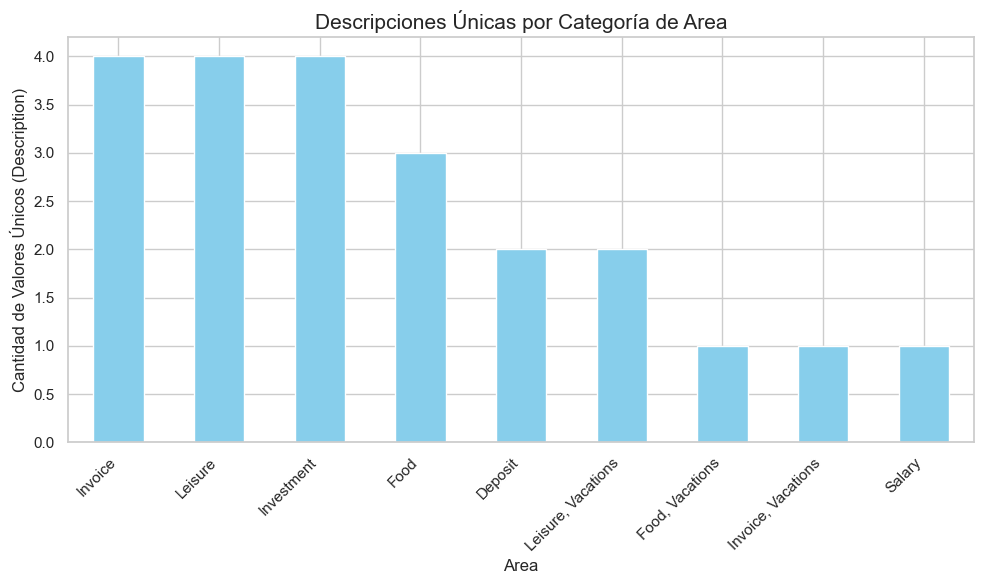

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

desc_uniques.plot(kind='bar', color='skyblue')
plt.title('Descripciones Únicas por Categoría de Area', fontsize=15)
plt.xlabel('Area', fontsize=12)
plt.ylabel('Cantidad de Valores Únicos (Description)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
# 5. Comparativa entre Datos de Train y Test

En esta sección comparamos los valores únicos presentes en los conjuntos de entrenamiento y prueba procesados.

In [6]:
# Definir rutas para train y test
train_path = Path("../data/processed/db_mod_descript_train.csv")
test_path = Path("../data/processed/db_mod_descript_test.csv")

# Cargar datasets
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Filas en Train: {len(df_train)}")
print(f"Filas en Test: {len(df_test)}")

Filas en Train: 442
Filas en Test: 443


## 5.1 Comparación de Categorías en 'Area'

¿Están todas las categorías representadas en ambos conjuntos?

In [7]:
areas_train = set(df_train['Area'].unique())
areas_test = set(df_test['Area'].unique())

print(f"Categorías de Area en Train ({len(areas_train)}): {areas_train}")
print(f"Categorías de Area en Test ({len(areas_test)}): {areas_test}")

solo_train = areas_train - areas_test
solo_test = areas_test - areas_train

if not solo_train and not solo_test:
    print("\n✅ ¡Ambos conjuntos contienen las mismas categorías de Area!")
else:
    if solo_train: print(f"\n⚠️ Categorías presentes solo en Train: {solo_train}")
    if solo_test: print(f"\n⚠️ Categorías presentes solo en Test: {solo_test}")

Categorías de Area en Train (9): {'Food, Vacations', 'Food', 'Deposit', 'Leisure', 'Salary', 'Investment', 'Invoice, Vacations', 'Invoice', 'Leisure, Vacations'}
Categorías de Area en Test (9): {'Food, Vacations', 'Food', 'Deposit', 'Leisure', 'Salary', 'Investment', 'Invoice, Vacations', 'Invoice', 'Leisure, Vacations'}

✅ ¡Ambos conjuntos contienen las mismas categorías de Area!


## 5.2 Conteo de Valores Únicos por Area (Train vs Test)

Comparamos cuántas descripciones únicas tiene cada categoría en cada conjunto.

Conteo de descripciones únicas por Area (Train vs Test):


,Train,Test
Area,,
Deposit,44,45
Food,88,88
"Food, Vacations",10,10
Investment,36,35
Invoice,120,121
"Invoice, Vacations",7,6
Leisure,87,88
"Leisure, Vacations",9,8
Salary,41,42


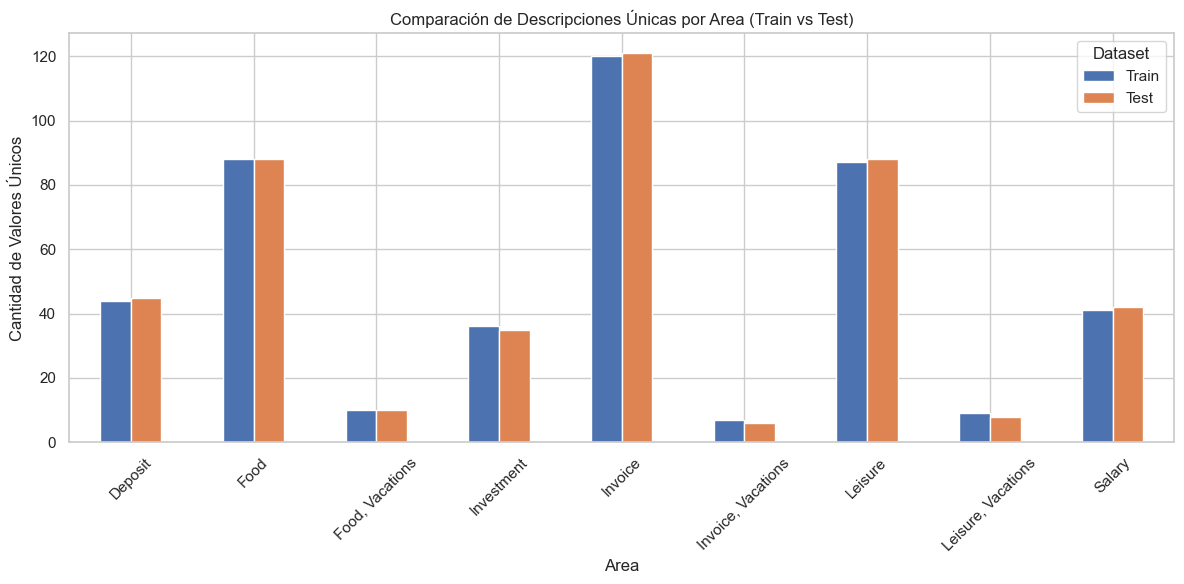

In [8]:
train_nunique = df_train.groupby('Area')['Description'].nunique().rename('Train')
test_nunique = df_test.groupby('Area')['Description'].nunique().rename('Test')

comparison_df = pd.concat([train_nunique, test_nunique], axis=1).fillna(0).astype(int)

print("Conteo de descripciones únicas por Area (Train vs Test):")
display(comparison_df)

# Visualización comparativa
comparison_df.plot(kind='bar', figsize=(12, 6))
plt.title('Comparación de Descripciones Únicas por Area (Train vs Test)')
plt.ylabel('Cantidad de Valores Únicos')
plt.xticks(rotation=45)
plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

## 5.3 Solapamiento de Descripciones (Train ∩ Test)

Analizamos qué descripciones exactas aparecen en ambos conjuntos de datos. Esto es importante para detectar posibles fugas de datos (*data leakage*) o ver qué patrones comunes se comparten.

In [9]:
desc_train = set(df_train['Description'].unique())
desc_test = set(df_test['Description'].unique())

intersection = desc_train.intersection(desc_test)

print(f"📌 Descripciones únicas en Train: {len(desc_train)}")
print(f"📌 Descripciones únicas en Test: {len(desc_test)}")
print(f"🔍 Descripciones que se repiten en ambos (solapamiento): {len(intersection)}")

if len(intersection) > 0:
    print("\nLista de algunas descripciones repetidas:")
    for i, desc in enumerate(list(intersection)[:10]): # Mostramos las primeras 10
        print(f"{i+1}. {desc}")
    if len(intersection) > 10:
        print("... (y otras más)")
else:
    print("\n✨ No hay solapamiento exacto de descripciones entre Train y Test.")

📌 Descripciones únicas en Train: 442
📌 Descripciones únicas en Test: 443
🔍 Descripciones que se repiten en ambos (solapamiento): 0

✨ No hay solapamiento exacto de descripciones entre Train y Test.


## 5.4 Listado de Descripciones Ordenadas (Alfabéticamente)

A continuación se muestran los listados de descripciones únicas encontradas en cada conjunto, ordenadas alfabéticamente.

In [10]:
desc_train_sorted = sorted(df_train['Description'].unique().tolist())
desc_test_sorted = sorted(df_test['Description'].unique().tolist())

print(f"--- MOSTRANDO TOP 20 DESCRIPCIONES DE TRAIN (Total: {len(desc_train_sorted)}) ---")
for d in desc_train_sorted[:20]:
    print(f"- {d}")
print("...")

print(f"\n--- MOSTRANDO TOP 20 DESCRIPCIONES DE TEST (Total: {len(desc_test_sorted)}) ---")
for d in desc_test_sorted[:20]:
    print(f"- {d}")
print("...")

--- MOSTRANDO TOP 20 DESCRIPCIONES DE TRAIN (Total: 442) ---
- Abono de nómina mensual - pago procesado
- Abono de nómina mensual de este mes
- Abono de nómina mensual del periodo actual
- Abono de nómina mensual mediante tarjeta
- Abono de nómina mensual registrado correctamente
- Abono de nómina mensual...
- Abono de nómina mensual....
- Abono de nómina mensual.....
- Abono de nómina mensual.......
- Abono de nómina mensual.........
- Abono de nómina mensual...........
- Actividad de ocio durante el viaje a Londres - pago procesado
- Actividad de ocio durante el viaje a Londres correspondiente a hoy
- Actividad de ocio durante el viaje a Londres registrado correctamente
- Actividad de ocio durante el viaje a París.
- Actividad de ocio durante el viaje a Valencia - pago procesado
- Actividad de ocio durante el viaje a el hotel Ritz
- Actividad de ocio durante el viaje a la playa
- Actividad de ocio durante el viaje a la playa - pago procesado
- Actividad de ocio durante el viaje a la 